# Smollm

In [1]:
!pip install -q transformers datasets torch accelerate tokenizers

import re, math, torch, numpy as np, pandas as pd
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
    EarlyStoppingCallback
)

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [4]:
print("="*60)
print("LOADING dair-ai/emotion")
print("="*60)

# Load the dair-ai/emotion dataset
dataset = load_dataset("dair-ai/emotion")

# The dair-ai/emotion dataset already has train, validation, and test splits.
# We will keep the dataset dictionary structure.
# If you need a single combined dataset, you can uncomment the following lines:
combined_df = concatenate_datasets([
    dataset["train"], dataset["validation"], dataset["test"]
])
print(f"Total samples (combined): {len(combined)}")

print(f"Dataset structure: {dataset}")
print(f"Train samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Test samples: {len(dataset['test'])}")

LOADING dair-ai/emotion
Total samples (combined): 20000
Dataset structure: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Train samples: 16000
Validation samples: 2000
Test samples: 2000


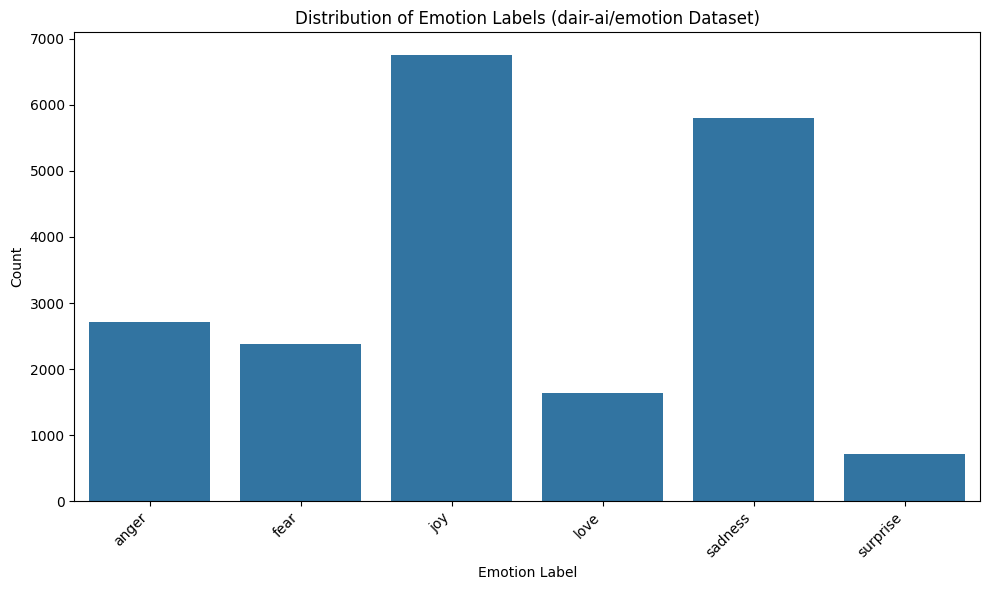


Distribution of Emotion Labels (Counts):
emotion
anger       2709
fear        2373
joy         6761
love        1641
sadness     5797
surprise     719
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import Dataset

# The dataset is a DatasetDict with train, validation, and test splits.
# We need to combine them for plotting the overall distribution.
combined_df = pd.concat([
    dataset["train"].to_pandas(),
    dataset["validation"].to_pandas(),
    dataset["test"].to_pandas()
])

# Define the mapping from numerical labels to emotion names for dair-ai/emotion
label_to_emotion = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

# Map the numerical labels to emotion names for plotting
combined_df['emotion'] = combined_df['label'].map(label_to_emotion)

# Get the value counts of the 'emotion' column for plotting
emotion_counts = combined_df['emotion'].value_counts().sort_index()

# Plot the distribution of the 'emotion' column
plt.figure(figsize=(10, 6)) # Increased figure size for better readability
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, order=emotion_counts.index) # Use emotion names on x-axis
plt.title('Distribution of Emotion Labels (dair-ai/emotion Dataset)')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

print("\nDistribution of Emotion Labels (Counts):")
print(emotion_counts)

In [7]:
from datasets import Dataset # Import Dataset here

print("="*60)
print("CLEANING DATA & ADDING CONTROL TOKENS")
print("="*60)

# Updated map for dair-ai/emotion labels
EMOTION_MAP = {
    0: "[SADNESS]",
    1: "[JOY]",
    2: "[LOVE]",
    3: "[ANGER]",
    4: "[FEAR]",
    5: "[SURPRISE]"
}


def clean_text(text):
    # Ensure the input is a string
    if not isinstance(text, str):
        return None
    text = re.sub(r'http\S+|@\w+|#', '', text)
    # Allow apostrophes, commas, periods, question marks, and exclamation points within words
    text = re.sub(r'[^A-Za-z0-9\s\'\.\,!?]', '', text)
    text = re.sub(r'([!?.,])\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Add a minimum length check and diversity check
    if len(text) < 20 or len(set(text.lower())) < 5: # Reduced diversity check to 5 unique characters
        return None
    return text

rows = []
# Use combined_df which contains the merged data from all splits
for index, row in combined_df.iterrows():
    cleaned = clean_text(row["text"])
    if cleaned:
        # Use the updated EMOTION_MAP
        if row["label"] in EMOTION_MAP:
            prefix = EMOTION_MAP[row["label"]]
            rows.append({"text": f"{prefix} {cleaned}", "label": row["label"]})
        else:
            print(f"Warning: Unexpected label found: {row['label']}")


cleaned_ds = Dataset.from_pandas(pd.DataFrame(rows))
print(f"After cleaning: {len(cleaned_ds)} samples")

CLEANING DATA & ADDING CONTROL TOKENS
After cleaning: 19819 samples


In [8]:
print("="*60)
print("CREATING BALANCED DATASET")
print("="*60)

df = cleaned_ds.to_pandas()
min_count = df["label"].value_counts().min()

balanced = []
# Balance all labels from 0 to 5
for label in range(6): # Iterate through all 6 labels (0 to 5)
    subset = cleaned_ds.filter(lambda x: x["label"] == label)
    balanced.append(subset.shuffle(seed=42).select(range(min_count)))

balanced_ds = concatenate_datasets(balanced).shuffle(seed=42)
print("Balanced size:", len(balanced_ds))
print(balanced_ds.to_pandas()["label"].value_counts())

CREATING BALANCED DATASET


Filter:   0%|          | 0/19819 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19819 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19819 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19819 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19819 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19819 [00:00<?, ? examples/s]

Balanced size: 4302
label
3    717
2    717
1    717
4    717
5    717
0    717
Name: count, dtype: int64


In [9]:
from datasets import ClassLabel

print("="*60)
print("TRAIN/TEST SPLIT")
print("="*60)

# Define the ClassLabel feature for emotion labels
emotion_classlabel = ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])

# Convert the 'label' column to ClassLabel type
balanced_ds = balanced_ds.cast_column('label', emotion_classlabel)

# Perform the train-test split with stratification
split = balanced_ds.train_test_split(test_size=0.1, seed=42, stratify_by_column="label")
train_ds, test_ds = split["train"], split["test"]

print(f"Train: {len(train_ds)} samples")
print(f"Test : {len(test_ds)} samples")

# Optional: Verify the class distribution in train and test sets
import pandas as pd
print("\nClass distribution in train set:")
print(pd.Series(train_ds['label']).value_counts(normalize=True))

print("\nClass distribution in test set:")
print(pd.Series(test_ds['label']).value_counts(normalize=True))

TRAIN/TEST SPLIT


Casting the dataset:   0%|          | 0/4302 [00:00<?, ? examples/s]

Train: 3871 samples
Test : 431 samples

Class distribution in train set:
0    0.166882
3    0.166624
5    0.166624
1    0.166624
2    0.166624
4    0.166624
Name: proportion, dtype: float64

Class distribution in test set:
2    0.167053
3    0.167053
1    0.167053
5    0.167053
4    0.167053
0    0.164733
Name: proportion, dtype: float64


In [10]:
print("="*60)
print("LOADING SmolLM-135M-Instruct")
print("="*60)

MODEL_NAME = "HuggingFaceTB/SmolLM-135M-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
tokenizer.add_special_tokens({
    "additional_special_tokens": ["[SADNESS]", "[JOY]", "[LOVE]", "[ANGER]", "[FEAR]", "[SURPRISE]"]
})
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map="auto")
model.resize_token_embeddings(len(tokenizer))
model.config.pad_token_id = tokenizer.eos_token_id

print(f"Model parameters: {model.num_parameters():,}")

LOADING SmolLM-135M-Instruct


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Model parameters: 134,518,464


In [11]:
print("="*60)
print("TOKENIZING DATASETS")
print("="*60)

max_length = 128

def tokenize_fn(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

tokenized_train = train_ds.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text","label"]
)
tokenized_test = test_ds.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text","label"]
)

print(f"Tokenized train: {len(tokenized_train)}")
print(f"Tokenized test : {len(tokenized_test)}")


TOKENIZING DATASETS


Map:   0%|          | 0/3871 [00:00<?, ? examples/s]

Map:   0%|          | 0/431 [00:00<?, ? examples/s]

Tokenized train: 3871
Tokenized test : 431


In [14]:
print("="*60)
print("SETTING UP TRAINING ARGUMENTS")
print("="*60)

training_args = TrainingArguments(
    output_dir="./smollm135m-sentiment",
    overwrite_output_dir=True,
    num_train_epochs=6,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.1,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    logging_steps=30,
    eval_strategy="steps",
    eval_steps=61,
    save_strategy="steps",
    save_steps=61,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    group_by_length=True,
    report_to="none",
    #callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

eff_batch = training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps
print(f"Effective batch size: {eff_batch}")


SETTING UP TRAINING ARGUMENTS
Effective batch size: 64


In [15]:
print("="*60)
print("INITIALIZING TRAINER")
print("="*60)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator
)

print("🚀 Starting training...")
train_result = trainer.train()
print(f"✅ Training loss: {train_result.training_loss:.4f}")

eval_results = trainer.evaluate()
print(f"📊 Eval loss  : {eval_results['eval_loss']:.4f}")
print(f"📊 Perplexity : {math.exp(eval_results['eval_loss']):.2f}")


INITIALIZING TRAINER
🚀 Starting training...


Step,Training Loss,Validation Loss
61,2.981200,3.972233
122,2.637900,4.169937
183,2.012200,4.659911
244,1.519000,5.289924
305,1.140500,5.818571
366,0.902700,6.149457


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


✅ Training loss: 1.8907


📊 Eval loss  : 3.9687
📊 Perplexity : 52.91


In [16]:
import os

# Define the directory to save the model and tokenizer
save_directory = "C:/Users/adria/OneDrive/Desktop/CODING/jupyter/major project 2/dairemotion/smollm"

# Create the directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

# Save the trained model
trainer.save_model(save_directory)

# Save the tokenizer
tokenizer.save_pretrained(save_directory)

print(f"Trained model and tokenizer saved to {save_directory}")

Trained model and tokenizer saved to C:/Users/adria/OneDrive/Desktop/CODING/jupyter/major project 2/dairemotion/smollm


In [17]:
import re

def generate_multiple_texts(prompt, model, tokenizer, device="cuda", num_outputs=5):
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,              # Sampling enabled for diversity
        temperature=0.75,
        top_k=40,
        top_p=0.9,
        repetition_penalty=1.3,
        length_penalty=1.2,
        num_beams=1,
        no_repeat_ngram_size=3,
        num_return_sequences=num_outputs,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_texts = []
    for output in outputs:
        text = tokenizer.decode(output, skip_special_tokens=True)
        # Clean output
        text = re.sub(r'([!?.,])\1+', r'\1', text)
        text = re.sub(r'[^A-Za-z0-9 \.\,!?]+', '', text)
        text = re.sub(r'\b(\w+)\1{2,}', r'\1', text)
        text = re.sub(r'\s+', ' ', text).strip()
        generated_texts.append(text)

    return generated_texts

# Emotion prefixes and a neutral prompt stem
emotions = ["[SADNESS]", "[JOY]", "[LOVE]", "[ANGER]", "[FEAR]", "[SURPRISE]"]
prompt_stem = "I feel"

all_samples = {}
num_samples_per_emotion = 3 # Reduced number of samples for quicker testing

for emotion in emotions:
    prompt = f"{emotion} {prompt_stem}"
    samples = generate_multiple_texts(prompt, model, tokenizer, num_outputs=num_samples_per_emotion)
    all_samples[emotion] = samples

# Print generative samples grouped by emotion
for emotion, samples in all_samples.items():
    print(f"\n===== Samples for emotion: {emotion} =====\n")
    for i, sample in enumerate(samples, 1):
        print(f"Sample {i}: {sample}\n")

The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



===== Samples for emotion: [SADNESS] =====

Sample 1: I feel like i am going to be really shitty with the whole thing and then my mom will have a big tantrum when she gets home from work since they are so excited about her wedding day but that is not going to happen this time around as

Sample 2: I feel so impressed with my team and the players that we have made all of these fantastic games last night but most particularly the last game in which i managed to score a goal or two as well as make some really great plays on screen against a tough opponent.

Sample 3: I feel like i was not as open with my mom when she first started telling me about her life and how it has changed over the years that have been so amazing to be sharing this time of year is one for the books only. She told me all those


===== Samples for emotion: [JOY] =====

Sample 1: I feel that he is a bit of a loner and doesnt want to be bothered with any work or projects so i would like him to have more time for his hob

# Dataset augmentation

In [3]:
import re
import random
import pandas as pd
from datasets import load_dataset, concatenate_datasets
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load original dair-ai/emotion dataset
dataset = load_dataset("dair-ai/emotion")
# Combine all splits for potential augmentation purposes
combined = concatenate_datasets([
    dataset["train"], dataset["validation"], dataset["test"]
])
# No need to take a subset for speed with this dataset size, but can keep if desired
# combined = dataset["train"].train_test_split(test_size=0.2, seed=42)["train"].select(range(30000))

# Load your fine-tuned generative model and tokenizer (SmolLM fine-tuned on dair-ai/emotion)
# Update the save_path to where you saved the SmolLM model fine-tuned on dair-ai/emotion
save_path = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\smollm"
model = AutoModelForCausalLM.from_pretrained(save_path).to("cuda")
tokenizer = AutoTokenizer.from_pretrained(save_path)

In [4]:
def generate_multiple_texts(prompt_list, model, tokenizer, device="cuda", num_outputs=1):
    generated_texts = []
    # Tokenize the entire batch of prompts
    inputs = tokenizer(prompt_list, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.75,
        top_k=40,
        top_p=0.9,
        repetition_penalty=1.3,
        length_penalty=1.2,
        num_beams=1,
        no_repeat_ngram_size=3,
        num_return_sequences=num_outputs,
        early_stopping=True,
        pad_token_id=tokenizer.eos_token_id
    )

    # Decode and clean the generated texts
    for output in outputs:
        text = tokenizer.decode(output, skip_special_tokens=True)
        # Clean output: remove the original prompt (this will be tricky with batching, might need a different approach or simpler cleaning),
        # remove special tokens again just in case, remove repeated punctuation,
        # remove non-alphanumeric characters except allowed ones, remove repeated words, and clean up whitespace.

        # A simpler cleaning approach for batch generation, focusing on removing the emotion prefix
        cleaned_text = re.sub(r'\[SADNESS\]|\[JOY\]|\[LOVE\]|\[ANGER\]|\[FEAR\]|\[SURPRISE\]', '', text) # Remove emotion prefix tokens
        cleaned_text = re.sub(r'([!?.,])\1+', r'\1', cleaned_text)
        cleaned_text = re.sub(r'[^A-Za-z0-9 \.\,!?\'\"]+', '', cleaned_text) # Added single and double quotes
        cleaned_text = re.sub(r'\b(\w+)\s+\1\b', r'\1', cleaned_text) # Remove immediate word repetitions
        cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

        # Add a minimum length check for generated text
        if len(cleaned_text) > 10: # Ensure generated text has some substance
             generated_texts.append(cleaned_text)
        else:
             # Optionally, log or handle cases where generated text is too short
             pass # print(f"Skipping short generated text: {cleaned_text}")


    return generated_texts

In [5]:
# Expand your seed prompts for maximum diversity based on emotion labels
seed_stems = {
    "[SADNESS]": [
        "I feel so sad because",
        "It makes me unhappy that",
        "I am feeling down today",
        "This situation is depressing",
        "I'm heartbroken over",
        "Feeling a deep sense of sorrow",
        "It's a gloomy day and I feel",
        "I can't help but feel melancholic about",
        "This news has made me feel terrible",
        "Experiencing a lot of sadness due to",
        "I feel like crying because",
        "Everything feels hopeless when",
        "Feeling utterly miserable about",
        "This loss is making me feel very low",
        "I feel a heavy heart because",
        "It's hard to feel happy when",
        "Feeling blue and discouraged by",
        "This disappointment makes me feel awful",
        "I'm in a state of sadness because",
        "Feeling utterly despondent about"
    ],
    "[JOY]": [
        "I am so happy because",
        "This makes me feel joyful",
        "Feeling absolutely delighted today",
        "I'm thrilled with",
        "Experiencing immense joy due to",
        "This is wonderful and makes me feel",
        "Feeling on top of the world because",
        "I'm so excited about",
        "This good news makes me feel great",
        "Feeling cheerful and optimistic about",
        "I feel like celebrating because",
        "Everything feels bright and I'm filled with",
        "Feeling utterly ecstatic about",
        "This success is making me feel very happy",
        "I feel a light heart because",
        "It's easy to feel happy when",
        "Feeling positive and uplifted by",
        "This achievement makes me feel fantastic",
        "I'm in a state of bliss because",
        "Feeling utterly exhilarated about"
    ],
    "[LOVE]": [
        "I feel so much love for",
        "This person makes me feel loved",
        "Feeling a deep connection with",
        "I'm fond of",
        "Experiencing immense affection for",
        "This relationship makes me feel warm and fuzzy",
        "Feeling a strong bond with",
        "I'm so grateful for",
        "This kindness makes me feel cherished",
        "Feeling loving and compassionate towards",
        "I feel like hugging because",
        "Everything feels beautiful and I'm filled with",
        "Feeling utterly devoted to",
        "This support is making me feel very loved",
        "I feel a tender heart because",
        "It's wonderful to feel love when",
        "Feeling affectionate and caring towards",
        "This gesture makes me feel deeply appreciated",
        "I'm in a state of adoration because",
        "Feeling utterly smitten with"
    ],
    "[ANGER]": [
        "I am so angry because",
        "This makes me feel furious",
        "Feeling absolutely enraged today",
        "I'm pissed off with",
        "Experiencing intense anger due to",
        "This situation makes me feel resentful",
        "Feeling a strong sense of irritation with",
        "I'm so frustrated about",
        "This unfairness makes me feel irate",
        "Feeling hostile and aggressive towards",
        "I feel like screaming because",
        "Everything feels wrong and I'm filled with",
        "Feeling utterly incensed about",
        "This betrayal is making me feel very angry",
        "I feel a burning rage because",
        "It's hard to stay calm when",
        "Feeling bitter and annoyed by",
        "This obstacle makes me feel furious",
        "I'm in a state of wrath because",
        "Feeling utterly exasperated about"
    ],
    "[FEAR]": [
        "I am so scared because",
        "This makes me feel fearful",
        "Feeling absolutely terrified today",
        "I'm afraid of",
        "Experiencing intense fear due to",
        "This situation makes me feel anxious",
        "Feeling a strong sense of dread about",
        "I'm so worried about",
        "This uncertainty makes me feel uneasy",
        "Feeling nervous and apprehensive about",
        "I feel like hiding because",
        "Everything feels dangerous and I'm filled with",
        "Feeling utterly petrified about",
        "This threat is making me feel very scared",
        "I feel a chilling fear because",
        "It's hard to feel safe when",
        "Feeling timid and insecure about",
        "This risk makes me feel frightened",
        "I'm in a state of panic because",
        "Feeling utterly alarmed about"
    ],
    "[SURPRISE]": [
        "I am so surprised because",
        "This makes me feel astonished",
        "Feeling absolutely amazed today",
        "I'm shocked by",
        "Experiencing intense surprise due to",
        "This news makes me feel startled",
        "Feeling a strong sense of wonder about",
        "I'm so taken aback by",
        "This unexpected event makes me feel bewildered",
        "Feeling astonished and impressed by",
        "I feel like gasping because",
        "Everything feels sudden and I'm filled with",
        "Feeling utterly astounded about",
        "This revelation is making me feel very surprised",
        "I feel a sense of awe because",
        "It's exciting to feel surprised when",
        "Feeling amazed and bewildered by",
        "This twist makes me feel shocked",
        "I'm in a state of disbelief because",
        "Feeling utterly flabbergasted about"
    ]
}

In [6]:
# Convert combined dataset to pandas for counting
df = pd.DataFrame(combined)

# Count label distribution
label_counts = df['label'].value_counts().sort_index()
print("Original label counts:")
print(label_counts)

max_count = label_counts.max()


Original label counts:
label
0    5797
1    6761
2    1641
3    2709
4    2373
5     719
Name: count, dtype: int64


In [7]:
label_map = {
    "[SADNESS]": 0,
    "[JOY]": 1,
    "[LOVE]": 2,
    "[ANGER]": 3,
    "[FEAR]": 4,
    "[SURPRISE]": 5
}

augmented_samples = {"text": [], "label": []}

batch_size = 32  # Increased batch size for faster generation

for sentiment_token, stems in seed_stems.items():
    # Ensure the sentiment token is in the label_map before proceeding
    if sentiment_token not in label_map:
        print(f"Warning: Sentiment token {sentiment_token} not found in label_map. Skipping.")
        continue

    label_int = label_map[sentiment_token]
    current_count = label_counts.get(label_int, 0)
    samples_needed = max_count - current_count
    if samples_needed <= 0:
        continue
    print(f"Generating {samples_needed} samples for {sentiment_token}...")

    generated_texts = []
    while len(generated_texts) < samples_needed:
        batch_prompts = []
        for _ in range(batch_size):
            if len(generated_texts) + len(batch_prompts) < samples_needed:
                stem = random.choice(stems)
                prompt = f"{sentiment_token} {stem}"
                batch_prompts.append(prompt)
            else:
                break

        if not batch_prompts:
            break

        # Generate texts for the batch
        new_texts = generate_multiple_texts(batch_prompts, model, tokenizer, num_outputs=1) # Assuming generate_multiple_texts now handles a list of prompts and returns a list of generated texts
        generated_texts.extend(new_texts)

        # Print progress
        if len(generated_texts) // 100 > (len(generated_texts) - len(new_texts)) // 100: # Print when a new multiple of 100 is reached
             print(f"Generated {len(generated_texts)} samples so far for {sentiment_token}.")


    generated_texts = generated_texts[:samples_needed]

    augmented_samples["text"].extend([f"{sentiment_token} {t}" for t in generated_texts])
    augmented_samples["label"].extend([label_int]*samples_needed)

print(f"Total synthetic samples generated: {len(augmented_samples['text'])}")

The following generation flags are not valid and may be ignored: ['early_stopping', 'length_penalty']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generating 964 samples for [SADNESS]...


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 128 samples so far for [SADNESS].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


...

Generated 5824 samples so far for [SURPRISE].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 5920 samples so far for [SURPRISE].


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Generated 6016 samples so far for [SURPRISE].
Total synthetic samples generated: 20566


In [8]:
aug_df = pd.DataFrame(augmented_samples)
combined_balanced_df = pd.concat([df.rename(columns={"text": "text", "label":"label"}), aug_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Combined dataset size: {len(combined_balanced_df)}")
print("Balanced label counts:")
print(combined_balanced_df["label"].value_counts())

Combined dataset size: 40566
Balanced label counts:
label
5    6761
2    6761
0    6761
1    6761
3    6761
4    6761
Name: count, dtype: int64


In [9]:
for sentiment_token in seed_stems.keys():
    # Filter the DataFrame for the current sentiment token
    sentiment_samples_df = aug_df[aug_df["text"].str.startswith(sentiment_token)]["text"]

    # Check if there are enough samples to take
    if len(sentiment_samples_df) >= 3:
        samples = sentiment_samples_df.sample(n=3, random_state=42).tolist()
        print(f"\n=== Samples for sentiment: {sentiment_token} ===")
        for i, sample in enumerate(samples, 1):
            print(f"Sample {i}: {sample}\n")
    else:
        print(f"\n=== Not enough samples generated for sentiment: {sentiment_token} ===")
        if len(sentiment_samples_df) > 0:
            print("Available samples:")
            for i, sample in enumerate(sentiment_samples_df.tolist(), 1):
                print(f"Sample {i}: {sample}\n")
        else:
            print("No samples generated for this sentiment.")


=== Samples for sentiment: [SADNESS] ===
Sample 1: [SADNESS] Experiencing a lot of sadness due toa traumatic event that occurred in the past or is happening again if you are not feeling your way through it as yet try and remember what happened without having feelings for them but they must have been so awful i feel surprised by this thing because its all

Sample 2: [SADNESS] I feel a heavy heart becauseI am not going to do anything about the whole affair until they are all in it for themselves and their own good reasons only if we can find one single person who will listen without feeling threatened or being offended by my presence on our side of the

Sample 3: [SADNESS] Everything feels hopeless when that one person is wronged by someone else and the other party seems to have no control over them or even their own feelings but they are never bothered about it at all in reality this is because of how much power each side has relative to others which


=== Not enough samples generated 

In [10]:
import os
import pandas as pd

# Define the local directory to save the dataset
save_directory_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion"

# Create the directory if it doesn't exist
os.makedirs(save_directory_local, exist_ok=True)

# Define the full path for the augmented dataset file
augmented_dataset_path_local = os.path.join(save_directory_local, "augmented_dair_emotion.csv")

# Save the augmented DataFrame to a CSV file
combined_balanced_df.to_csv(augmented_dataset_path_local, index=False)

print(f"Augmented dataset saved to {augmented_dataset_path_local}")

Augmented dataset saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\augmented_dair_emotion.csv


# Roberta augmented dataset


## Load Augmented Dataset

### Subtask:
Load the augmented dataset from the local path.

In [1]:
import pandas as pd
import os

# Define the local path to the augmented dataset
augmented_dataset_path_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\augmented_dair_emotion.csv"

# Load the augmented dataset
augmented_df = pd.read_csv(augmented_dataset_path_local)

# Display the shape of the loaded DataFrame
print(f"Shape of the loaded augmented dataset: {augmented_df.shape}")

# Display the first few rows
display(augmented_df.head())

Shape of the loaded augmented dataset: (40566, 2)


,text,label
0,[SURPRISE] This makes me feel astonishedI can ...,5
1,[LOVE] Feeling a deep connection witha mysteri...,2
2,[SURPRISE] It's exciting to feel surprised whe...,5
3,ive blogged and i feel strange about it,5
4,[SURPRISE] Feeling astonished and impressed by...,5


## Clean and Preprocess Data

### Subtask:
Clean and preprocess the text data to remove noise and standardize the format.

**Reasoning**:
Inspect `augmented_df` for missing values, handle them by dropping rows with missing text, apply the existing `clean_text` function to create a 'cleaned_text' column, and then display the head of the updated DataFrame.

In [2]:
import re

def clean_text(text):
    # Check if the input is a string before applying string methods
    if not isinstance(text, str):
        return "" # Return an empty string for non-string inputs (like NaN)

    # Remove emotion prefix tokens like [SADNESS], [JOY], etc.
    text = re.sub(r'\[SADNESS\]|\[JOY\]|\[LOVE\]|\[ANGER\]|\[FEAR\]|\[SURPRISE\]', '', text)

    # Convert to lowercase
    text = text.lower()
    # Remove mentions (@user) and URLs (http\S+)
    text = re.sub(r'(@\w+|http\S+)', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Check for missing values before cleaning
print("Missing values before cleaning:")
print(augmented_df.isnull().sum())

# Handle missing values: Drop rows where 'text' is missing as cleaning requires text
augmented_df.dropna(subset=['text'], inplace=True)

# Apply the clean_text function to the 'text' column
augmented_df['cleaned_text'] = augmented_df['text'].apply(clean_text)

# Display the first few rows of the augmented DataFrame with the new 'cleaned_text' column
display(augmented_df[['text', 'cleaned_text', 'label']].tail())

# Display the shape after cleaning
print(f"Shape of the augmented DataFrame after cleaning: {augmented_df.shape}")

Missing values before cleaning:
text     0
label    0
dtype: int64


,text,cleaned_text,label
40561,i came close to just packing up and heading ho...,i came close to just packing up and heading ho...,0
40562,i want to savor this feeling of ecstatic antic...,i want to savor this feeling of ecstatic antic...,1
40563,[SURPRISE] Feeling amazed and bewildered bythe...,feeling amazed and bewildered bythe sheer magn...,5
40564,i was starting to feel a little stressed,i was starting to feel a little stressed,0
40565,i feel stressed tired worn out out of shape or...,i feel stressed tired worn out out of shape or...,0


Shape of the augmented DataFrame after cleaning: (40566, 3)


**Reasoning**:
Load the augmented dataset from the specified local path into a pandas DataFrame and display its shape and the first few rows to verify it loaded correctly.

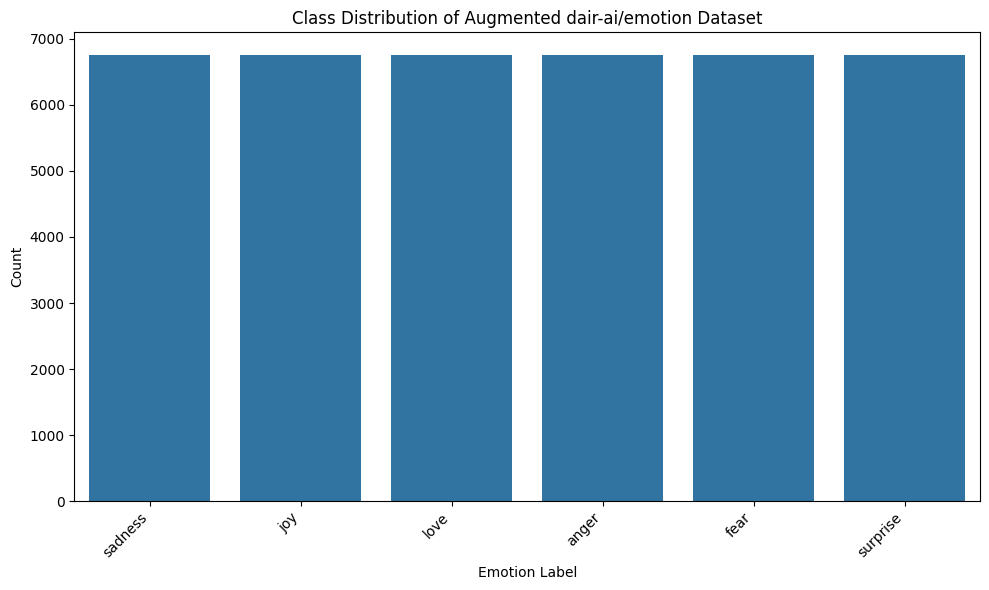


Class Distribution (Counts):
emotion
anger       6761
fear        6761
joy         6761
love        6761
sadness     6761
surprise    6761
Name: count, dtype: int64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming augmented_df is already loaded and cleaned with 'label' column

# Define the mapping from numerical labels to emotion names for dair-ai/emotion
label_to_emotion = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

# Map the numerical labels to emotion names for plotting
augmented_df['emotion'] = augmented_df['label'].map(label_to_emotion)

# Plot the class distribution of the augmented dataset
plt.figure(figsize=(10, 6)) # Increased figure size for better readability
sns.countplot(x='emotion', data=augmented_df, order=label_to_emotion.values()) # Use emotion names and define order
plt.title('Class Distribution of Augmented dair-ai/emotion Dataset')
plt.xlabel('Emotion Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Optional: Print the counts
print("\nClass Distribution (Counts):")
print(augmented_df['emotion'].value_counts().sort_index())

## Split Data

### Subtask:
Split the balanced dataset into training and testing sets, ensuring the class distribution is maintained using stratification.

**Reasoning**:
Split the balanced dataset into training and testing sets while maintaining class distribution using stratification.

In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = augmented_df['cleaned_text']
y = augmented_df['label']

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the shapes of the resulting sets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (32452,)
Shape of X_test: (8114,)
Shape of y_train: (32452,)
Shape of y_test: (8114,)


## Tokenize Data

### Subtask:
Tokenize the text data for the RoBERTa model.

In [5]:
from transformers import AutoTokenizer
import torch

# Load the pretrained RoBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained('roberta-base')

# Tokenize the training and testing sets
# Ensure padding and truncation are applied with a suitable maximum length
train_encodings = tokenizer(list(X_train), truncation=True, padding='max_length', max_length=128, return_tensors="pt")
test_encodings = tokenizer(list(X_test), truncation=True, padding='max_length', max_length=128, return_tensors="pt")

# Convert labels to PyTorch tensors
train_labels = torch.tensor(y_train.values)
test_labels = torch.tensor(y_test.values)

print("Tokenization complete and data converted to PyTorch tensors.")

Tokenization complete and data converted to PyTorch tensors.


## Define Dataset Class

### Subtask:
Create a custom PyTorch Dataset class to handle the tokenized data and labels.

**Reasoning**:
Define a custom PyTorch Dataset class to encapsulate the tokenized inputs and labels, making it compatible with PyTorch DataLoaders and the Hugging Face Trainer.

In [6]:
import torch
from torch.utils.data import Dataset

class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        # Pass the label directly as it's already a tensor
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

print("Custom Dataset class defined.")

Custom Dataset class defined.


**Reasoning**:
Import the RoBERTa tokenizer, load the pretrained tokenizer, tokenize the training and testing data with padding and truncation, and convert the tokenized outputs to PyTorch tensors.

## Load RoBERTa Model

### Subtask:
Load a pretrained RoBERTa model for sequence classification.

**Reasoning**:
Load a pretrained RoBERTa model for sequence classification and print a confirmation message.

In [7]:
from transformers import AutoModelForSequenceClassification

# Load a pretrained RoBERTa model for sequence classification with 3 output labels (for negative, neutral, positive)
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=6)

print("Pretrained RoBERTa model loaded successfully.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pretrained RoBERTa model loaded successfully.


## Implement Hyperparameter Search

### Subtask:
Implement hyperparameter search using Optuna for learning rate and number of epochs.

**Reasoning**:
Define the model initialization function, the objective function for Optuna to optimize (based on evaluation metric), create and run the Optuna study, and print the best hyperparameters found.

In [8]:
!pip install accelerate -U

In [10]:
import optuna
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import torch
from torch.utils.data import Dataset # Import Dataset

# Assuming train_encodings, test_encodings, train_labels, and test_labels are already created

# Define a custom PyTorch Dataset class
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Instantiate the custom Dataset for training and testing data
train_dataset = TweetDataset(train_encodings, train_labels)
test_dataset = TweetDataset(test_encodings, test_labels)


# Define a function to compute metrics for evaluation
def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    # Update target_names for the classification report to reflect emotion labels
    emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted')
    acc = accuracy_score(p.label_ids, preds)
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        # You can also add a classification report string for detailed insights
        # 'report': classification_report(p.label_ids, preds, target_names=emotion_names)
    }

# Define the model_init function for Optuna
def model_init(trial):
    # Load a pretrained RoBERTa model for sequence classification with 6 output labels (for emotion classes)
    return AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=6)

# Define the objective function for Optuna
def objective(trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True)
    num_train_epochs = trial.suggest_int("num_train_epochs", 1, 3) # Search between 1 and 3 epochs

    # Define training arguments with suggested hyperparameters and mixed precision
    training_args = TrainingArguments(
        output_dir='./results',          # output directory for checkpoints
        num_train_epochs=num_train_epochs,              # number of training epochs from Optuna trial
        per_device_train_batch_size=32,   # batch size per device during training
        per_device_eval_batch_size=32,   # batch size per device during evaluation
        weight_decay=0.01,               # weight decay
        logging_dir='./logs',            # directory for storing logs
        logging_steps=100,               # number of update steps before logging
        eval_strategy='epoch',     # evaluate at the end of each epoch
        save_strategy='epoch',           # save at the end of each epoch
        load_best_model_at_end=True,     # load the best model based on the evaluation metric at the end of training
        metric_for_best_model='eval_f1', # metric to monitor for selecting the best model - Using F1-score
        fp16=torch.cuda.is_available(),                       # Enable mixed precision training
        learning_rate=learning_rate,      # Use suggested learning rate
        report_to="none" # Disable reporting to Weights & Biases
    )

    # Instantiate the Trainer object
    trainer = Trainer(
        model_init=model_init, # Use model_init for hyperparameter search
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )

    # Train the model
    trainer.train()

    # Evaluate the model on the test set and return the metric to optimize
    eval_result = trainer.evaluate()
    return eval_result["eval_f1"] # Return the evaluation F1 score for maximization


# Create an Optuna study and optimize the objective function
# We aim to maximize the evaluation F1 score
#study = optuna.create_study(direction="maximize")
#study.optimize(objective, n_trials=2) # Set a reasonable number of trials

# Print the best trial's parameters
#print("Best trial:")
#print("  Value (Evaluation F1 Score): {}".format(study.best_trial.value))
#print("  Params: ")
#for key, value in study.best_trial.params.items():
 #   print("    {}: {}".format(key, value))

## Train Model with Best Hyperparameters

### Subtask:
Train the RoBERTa classifier using the best hyperparameters from Optuna.

**Reasoning**:
Retrieve the best hyperparameters from the Optuna study, define the `TrainingArguments` using these parameters, load a new instance of the RoBERTa model, create a `Trainer` instance with the best model and arguments, and start the training process.

In [11]:
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification, EarlyStoppingCallback
import torch



# Updated TrainingArguments for better generalization
training_args = TrainingArguments(
    output_dir='./results_best_run',
    num_train_epochs=5, # Use best epoch count, default to 3
    learning_rate=5e-5, # Use best learning rate, default to 5e-5
    per_device_train_batch_size=32, # Use best batch size, default to 32
    per_device_eval_batch_size=32, # Use best batch size, default to 32
    gradient_accumulation_steps=2,      # effective batch doubling
    warmup_ratio=0.1,                   # 10% warmup
    weight_decay=0.01,
    logging_dir='./logs_best_run',
    logging_steps=50,
    eval_strategy='steps',        # evaluate during training
    eval_steps=100,                     # every 100 steps
    save_strategy='steps',
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model='eval_f1',
    greater_is_better=True,
    fp16=torch.cuda.is_available(),
    group_by_length=True,
    report_to="none",
    save_total_limit=3,
    seed=42
)

# Load model with 6 labels for emotion classification
model = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=6)

# Trainer with early stopping on eval_f1
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # Corrected typo: early_stopping_patience
)

print("Starting training with improved settings...")
trainer.train()
print("Training complete.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting training with improved settings...


C:\Users\adria\AppData\Local\Temp\ipykernel_65032\1964218888.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_65032\1964218888.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
100,1.051100,0.527367,0.843111,0.864075,0.843111,0.847039
200,0.288300,0.216160,0.932216,0.932882,0.932216,0.932186
300,0.223800,0.155510,0.951072,0.951408,0.951072,0.951033
400,0.141300,0.138994,0.956125,0.957280,0.956125,0.956221
500,0.138400,0.100622,0.962041,0.962388,0.962041,0.962032
600,0.123100,0.112875,0.961425,0.961937,0.961425,0.961506
700,0.110500,0.089630,0.965738,0.966268,0.965738,0.965793
800,0.080500,0.101428,0.963766,0.964090,0.963766,0.963769
900,0.093400,0.079261,0.965368,0.966006,0.965368,0.965366
1000,0.095400,0.074620,0.967094,0.968003,0.967094,0.967011


C:\Users\adria\AppData\Local\Temp\ipykernel_65032\1964218888.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_65032\1964218888.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])
C:\Users\adria\AppData\Local\Temp\ipykernel_65032\1964218888.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:

Training complete.


## Save the Fine-tuned Model

### Subtask:
Save the fine-tuned RoBERTa model and tokenizer to the specified local path.

**Reasoning**:
Define the local save path, create the directory if it doesn't exist, save the model using the `trainer.save_model()` method, save the tokenizer using the `tokenizer.save_pretrained()` method, and print a confirmation message.

In [12]:
import os

# Define the local path to save the model
save_path_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\roberta_classifieraugmented"

# Create the directory if it doesn't exist
os.makedirs(save_path_local, exist_ok=True)

# Save the model using the trainer
trainer.save_model(save_path_local)

# Save the tokenizer (assuming 'tokenizer' object is still available from tokenization step)
tokenizer.save_pretrained(save_path_local)

print(f"RoBERTa model and tokenizer saved to {save_path_local}")

RoBERTa model and tokenizer saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\roberta_classifieraugmented


## Generate Classification Report and Confusion Matrix

### Subtask:
Generate a classification report and confusion matrix for the trained RoBERTa model on the test set.

**Reasoning**:
Use the trained `trainer` object to get predictions on the `test_dataset`, then use `sklearn.metrics.classification_report` and `sklearn.metrics.confusion_matrix` to generate and print the report and matrix.

In [13]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Define the local path where the model and tokenizer are saved
load_path_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\roberta_classifieraugmented"

# Load the trained model and tokenizer
loaded_model = AutoModelForSequenceClassification.from_pretrained(load_path_local)
loaded_tokenizer = AutoTokenizer.from_pretrained(load_path_local)

print(f"Model and tokenizer loaded from {load_path_local}")

Model and tokenizer loaded from C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\roberta_classifieraugmented


C:\Users\adria\AppData\Local\Temp\ipykernel_65032\1964218888.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_65032\1964218888.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Classification Report:
              precision    recall  f1-score   support

     sadness       0.98      0.98      0.98      1352
         joy       0.96      0.95      0.96      1352
        love       0.97      0.97      0.97      1352
       anger       0.98      0.97      0.97      1353
        fear       0.96      0.98      0.97      1353
    surprise       0.98      0.97      0.98      1352

    accuracy                           0.97      8114
   macro avg       0.97      0.97      0.97      8114
weighted avg       0.97      0.97      0.97      8114



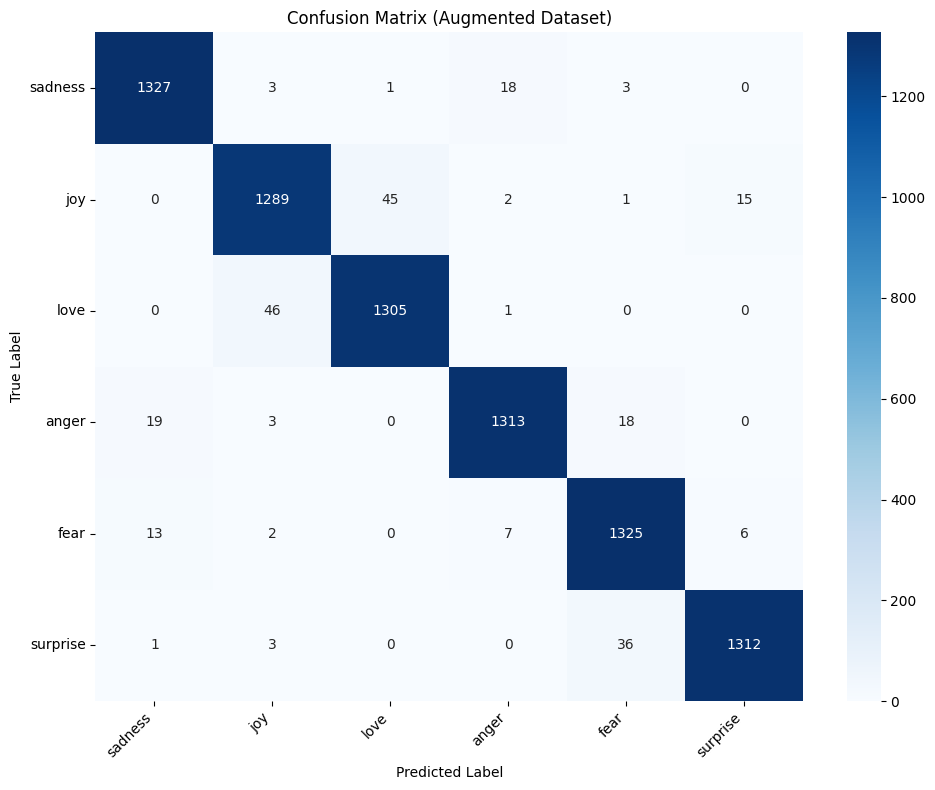

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch # Import torch
from torch.utils.data import DataLoader # Import DataLoader


# Ensure the loaded model is in evaluation mode and on the correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model.to(device)
loaded_model.eval()

# Create a DataLoader for the test dataset
test_dataloader = DataLoader(test_dataset, batch_size=32) # Assuming batch_size=32 is appropriate

predictions = []
true_labels = []

# Get predictions on the test dataset using the loaded model
with torch.no_grad():
    for batch in test_dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device) # Get labels from the batch

        outputs = loaded_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())


# Define the target names for the classification report and confusion matrix
emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Generate classification report
print("Classification Report:")
print(classification_report(true_labels, predictions, target_names=emotion_names))

# Generate confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8)) # Increased figure size
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_names, yticklabels=emotion_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Augmented Dataset)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Roberta og dataset


## Load the original dataset

### Subtask:
Load the "cardiffnlp/tweet_eval" dataset with the "sentiment" configuration.


**Reasoning**:
Load the specified dataset and print its structure to understand its composition.



In [1]:
from datasets import load_dataset

# Load the "dair-ai/emotion" dataset
original_dataset = load_dataset("dair-ai/emotion")

# Print the structure of the loaded dataset
print(original_dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


## Clean and preprocess data

### Subtask:
Clean and preprocess the text data from the original dataset by removing mentions, URLs, and punctuation, and handle any missing values.


**Reasoning**:
Concatenate the dataset splits, convert to pandas, handle missing values, define and apply the cleaning function, and display the results and shape.



In [3]:
import re
import pandas as pd
from datasets import concatenate_datasets

# Concatenate the dataset splits
combined_original = concatenate_datasets([
    original_dataset["train"],
    original_dataset["validation"],
    original_dataset["test"]
])

# Convert to pandas DataFrame
original_df = pd.DataFrame(combined_original)

# Check for missing values before cleaning
print("Missing values before cleaning:")
print(original_df.isnull().sum())

# Handle missing values: Drop rows where 'text' is missing
original_df.dropna(subset=['text'], inplace=True)

# Define the cleaning function
def clean_text_original(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'(@\w+|http\S+)', '', text) # Remove mentions and URLs
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra whitespace
    return text

# Apply the cleaning function
original_df['cleaned_text'] = original_df['text'].apply(clean_text_original)

# Display the first few rows
display(original_df[['text', 'cleaned_text', 'label']].head())

# Print the shape after cleaning
print(f"Shape of the original DataFrame after cleaning: {original_df.shape}")

Missing values before cleaning:
text     0
label    0
dtype: int64


,text,cleaned_text,label
0,i didnt feel humiliated,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,i am feeling grouchy,3


Shape of the original DataFrame after cleaning: (20000, 3)


## Split data

### Subtask:
Split the cleaned original dataset into training and testing sets.


**Reasoning**:
Split the cleaned original dataset into training and testing sets.



In [4]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variable (y)
X = original_df['cleaned_text']
y = original_df['label']

# Split the dataset into training and testing sets
X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting sets
print(f"Shape of X_train_original: {X_train_original.shape}")
print(f"Shape of X_test_original: {X_test_original.shape}")
print(f"Shape of y_train_original: {y_train_original.shape}")
print(f"Shape of y_test_original: {y_test_original.shape}")

Shape of X_train_original: (16000,)
Shape of X_test_original: (4000,)
Shape of y_train_original: (16000,)
Shape of y_test_original: (4000,)


## Tokenize data

### Subtask:
Tokenize the text data using the RoBERTa tokenizer.


**Reasoning**:
Import the necessary tokenizer, load it, and tokenize the training and testing data, then convert labels to tensors.



In [5]:
from transformers import AutoTokenizer
import torch

# Load the pretrained RoBERTa tokenizer
tokenizer_original = AutoTokenizer.from_pretrained('roberta-base')

# Tokenize the training and testing sets
# Ensure padding and truncation are applied with a suitable maximum length
train_encodings_original = tokenizer_original(list(X_train_original), truncation=True, padding='max_length', max_length=128, return_tensors="pt")
test_encodings_original = tokenizer_original(list(X_test_original), truncation=True, padding='max_length', max_length=128, return_tensors="pt")

# Convert labels to PyTorch tensors
train_labels_original = torch.tensor(y_train_original.values)
test_labels_original = torch.tensor(y_test_original.values)

print("Tokenization complete and data converted to PyTorch tensors.")

Tokenization complete and data converted to PyTorch tensors.


## Define dataset class

### Subtask:
Create a custom PyTorch Dataset class to handle the tokenized data and labels.


**Reasoning**:
Define a custom PyTorch Dataset class to encapsulate the tokenized inputs and labels, making it compatible with PyTorch DataLoaders and the Hugging Face Trainer.



In [6]:
import torch
from torch.utils.data import Dataset

class TweetDatasetOriginal(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

print("Custom Dataset class defined.")

Custom Dataset class defined.


## Load roberta model

### Subtask:
Load a pretrained RoBERTa model for sequence classification.


**Reasoning**:
Load a pretrained RoBERTa model for sequence classification and print a confirmation message.



In [11]:
from transformers import AutoModelForSequenceClassification

# Load a pretrained RoBERTa model for sequence classification with 6 output labels (for emotion classes)
model_original = AutoModelForSequenceClassification.from_pretrained('roberta-base', num_labels=6)

print("Pretrained RoBERTa model loaded successfully.")

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Pretrained RoBERTa model loaded successfully.


**Reasoning**:
Instantiate the custom dataset class for the original training and testing data.



In [8]:
# Instantiate the custom Dataset for original training and testing data
train_dataset_original = TweetDatasetOriginal(train_encodings_original, train_labels_original)
test_dataset_original = TweetDatasetOriginal(test_encodings_original, test_labels_original)

print("Original training and testing datasets instantiated.")

Original training and testing datasets instantiated.


**Reasoning**:
Define the training arguments and initialize the Trainer with the original datasets and model, then start training.



In [10]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report # Import classification_report
import numpy as np
import torch

# Define a function to compute metrics for evaluation
def compute_metrics_original(p):
    preds = p.predictions.argmax(-1)
    # Define target names for the classification report
    emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, preds, average='weighted')
    acc = accuracy_score(p.label_ids, preds)
    report = classification_report(p.label_ids, preds, target_names=emotion_names, output_dict=True) # Generate classification report as dict
    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'report': report # Include the classification report
    }

# Define training arguments
training_args_original = TrainingArguments(
    output_dir='./results_original',          # output directory
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=32,   # batch size per device during training
    per_device_eval_batch_size=32,   # batch size per device during evaluation
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs_original',            # directory for storing logs
    logging_steps=100,               # log every 100 steps
    eval_strategy='epoch',    # evaluate at the end of each epoch
    save_strategy='epoch',          # save at the end of each epoch
    load_best_model_at_end=True,     # load the best model based on eval_loss at the end of training
    metric_for_best_model='eval_loss', # metric to monitor for early stopping
    greater_is_better=False,         # for eval_loss, smaller is better
    fp16=torch.cuda.is_available(), # Enable mixed precision if CUDA is available
    report_to="none" # Disable reporting to Weights & Biases
)

# Initialize the Trainer
trainer_original = Trainer(
    model=model_original,
    args=training_args_original,
    train_dataset=train_dataset_original,
    eval_dataset=test_dataset_original,
    compute_metrics=compute_metrics_original
)

print("Starting training of the original model...")
# Start training
trainer_original.train()
print("Training of the original model complete.")

Starting training of the original model...


C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Report
1,0.247100,0.170949,0.931000,0.934590,0.931000,0.931062,"{'sadness': {'precision': 0.9656328583403185, 'recall': 0.9640167364016736, 'f1-score': 0.964824120603015, 'support': 1195.0}, 'joy': {'precision': 0.974822974036192, 'recall': 0.9280898876404494, 'f1-score': 0.9508825786646201, 'support': 1335.0}, 'love': {'precision': 0.8036175710594315, 'recall': 0.9367469879518072, 'f1-score': 0.8650904033379694, 'support': 332.0}, 'anger': {'precision': 0.9169675090252708, 'recall': 0.9407407407407408, 'f1-score': 0.9287020109689214, 'support': 540.0}, 'fear': {'precision': 0.8450413223140496, 'recall': 0.9253393665158371, 'f1-score': 0.8833693304535637, 'support': 442.0}, 'surprise': {'precision': 0.9459459459459459, 'recall': 0.6730769230769231, 'f1-score': 0.7865168539325843, 'support': 156.0}, 'accuracy': 0.931, 'macro avg': {'precision': 0.9086713634535347, 'recall': 0.8946684403879052, 'f1-score': 0.896564216326779, 'support': 4000.0}, 'weighted avg': {'precision': 0.934589814137688, 'recall': 0.931, 'f1-score': 0.9310620099358132, 'support': 4000.0}}"
2,0.129500,0.125630,0.934750,0.939224,0.934750,0.935929,"{'sadness': {'precision': 0.9896193771626297, 'recall': 0.9573221757322176, 'f1-score': 0.9732028923862186, 'support': 1195.0}, 'joy': {'precision': 0.9735202492211839, 'recall': 0.9363295880149812, 'f1-score': 0.9545628102329133, 'support': 1335.0}, 'love': {'precision': 0.8036175710594315, 'recall': 0.9367469879518072, 'f1-score': 0.8650904033379694, 'support': 332.0}, 'anger': {'precision': 0.9172661870503597, 'recall': 0.9444444444444444, 'f1-score': 0.9306569343065694, 'support': 540.0}, 'fear': {'precision': 0.8962264150943396, 'recall': 0.8597285067873304, 'f1-score': 0.8775981524249422, 'support': 442.0}, 'surprise': {'precision': 0.7461139896373057, 'recall': 0.9230769230769231, 'f1-score': 0.8252148997134671, 'support': 156.0}, 'accuracy': 0.93475, 'macro avg': {'precision': 0.8877272982042084, 'recall': 0.9262747710012841, 'f1-score': 0.9043876820670134, 'support': 4000.0}, 'weighted avg': {'precision': 0.9392238302184165, 'recall': 0.93475, 'f1-score': 0.9359288685558372, 'support': 4000.0}}"
3,0.094500,0.127057,0.935750,0.937553,0.935750,0.935173,"{'sadness': {'precision': 0.985445205479452, 'recall': 0.9631799163179916, 'f1-score': 0.9741853575962759, 'support': 1195.0}, 'joy': {'precision': 0.9476787030213707, 'recall': 0.9632958801498127, 'f1-score': 0.9554234769687965, 'support': 1335.0}, 'love': {'precision': 0.8571428571428571, 'recall': 0.8313253012048193, 'f1-score': 0.8440366972477065, 'support': 332.0}, 'anger': {'precision': 0.9398496240601504, 'recall': 0.9259259259259259, 'f1-score': 0.9328358208955224, 'support': 540.0}, 'fear': {'precision': 0.8352941176470589, 'recall': 0.9638009049773756, 'f1-score': 0.8949579831932774, 'support': 442.0}, 'surprise': {'precision': 0.9369369369369369, 'recall': 0.6666666666666666, 'f1-score': 0.7790262172284644, 'support': 156.0}, 'accuracy': 0.93575, 'macro avg': {'precision': 0.9170579073813044, 'recall': 0.8856990992070987, 'f1-score': 0.8967442588550072, 'support': 4000.0}, 'weighted avg': {'precision': 0.9375526192018867, 'recall': 0.93575, 'f1-score': 0.9351732223274456, 'support': 4000.0}}"


C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])
C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:

Training of the original model complete.


## Evaluate the model

### Subtask:
Evaluate the trained model on the test set and print the evaluation metrics.

**Reasoning**:
Use the trained `trainer_original` object to evaluate the model on the `test_dataset_original` and print the resulting evaluation metrics.

In [12]:
# Evaluate the trained model on the test dataset
eval_results_original = trainer_original.evaluate()

# Print the evaluation results
print("Evaluation results for the original model:")
print(eval_results_original)

C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Evaluation results for the original model:
{'eval_loss': 0.1256299614906311, 'eval_accuracy': 0.93475, 'eval_precision': 0.9392238302184165, 'eval_recall': 0.93475, 'eval_f1': 0.9359288685558372, 'eval_report': {'sadness': {'precision': 0.9896193771626297, 'recall': 0.9573221757322176, 'f1-score': 0.9732028923862186, 'support': 1195.0}, 'joy': {'precision': 0.9735202492211839, 'recall': 0.9363295880149812, 'f1-score': 0.9545628102329133, 'support': 1335.0}, 'love': {'precision': 0.8036175710594315, 'recall': 0.9367469879518072, 'f1-score': 0.8650904033379694, 'support': 332.0}, 'anger': {'precision': 0.9172661870503597, 'recall': 0.9444444444444444, 'f1-score': 0.9306569343065694, 'support': 540.0}, 'fear': {'precision': 0.8962264150943396, 'recall': 0.8597285067873304, 'f1-score': 0.8775981524249422, 'support': 442.0}, 'surprise': {'precision': 0.7461139896373057, 'recall': 0.9230769230769231, 'f1-score': 0.8252148997134671, 'support': 156.0}, 'accuracy': 0.93475, 'macro avg': {'preci

## Generate Classification Report and Confusion Matrix

### Subtask:
Generate a classification report and confusion matrix for the trained RoBERTa model on the test set.

**Reasoning**:
Use the trained `trainer_original` object to get predictions on the `test_dataset_original`, then use `sklearn.metrics.classification_report` and `sklearn.metrics.confusion_matrix` to generate and print the report and matrix.

In [13]:
import os

# Define the local path to save the model
save_path_local_original = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\roberta_classifierog"

# Create the directory if it doesn't exist
os.makedirs(save_path_local_original, exist_ok=True)

# Save the model using the trainer
trainer_original.save_model(save_path_local_original)

# Save the tokenizer (assuming 'tokenizer_original' object is still available)
tokenizer_original.save_pretrained(save_path_local_original)

print(f"Original RoBERTa model and tokenizer saved to {save_path_local_original}")

Original RoBERTa model and tokenizer saved to C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\roberta_classifierog


## Load Model and Generate Classification Report

### Subtask:
Load the trained RoBERTa model and tokenizer and generate a classification report on the test set.

**Reasoning**:
Load the model and tokenizer from the saved path, use the loaded model to make predictions on the test dataset, and then generate and print the classification report using `sklearn.metrics.classification_report`.

In [15]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Define the local path where the model and tokenizer are saved
load_path_local = r"C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\roberta_classifierog"

# Load the trained model and tokenizer
loaded_model = AutoModelForSequenceClassification.from_pretrained(load_path_local)
loaded_tokenizer = AutoTokenizer.from_pretrained(load_path_local)

print(f"Model and tokenizer loaded from {load_path_local}")

Model and tokenizer loaded from C:\Users\adria\OneDrive\Desktop\CODING\jupyter\major project 2\dairemotion\roberta_classifierog


In [16]:
from sklearn.metrics import classification_report
import torch
from torch.utils.data import DataLoader

# Ensure the loaded model is in evaluation mode and on the correct device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loaded_model.to(device)
loaded_model.eval()

# Create a DataLoader for the original test dataset
test_dataloader_original = DataLoader(test_dataset_original, batch_size=32) # Assuming test_dataset_original is defined and appropriate batch_size=32

predictions = []
true_labels = []

# Get predictions on the original test dataset using the loaded model
with torch.no_grad():
    for batch in test_dataloader_original:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = loaded_model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=-1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Define the target names for the classification report (emotion labels)
emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Generate classification report
print("Classification Report (Loaded Original Model):")
print(classification_report(true_labels, predictions, target_names=emotion_names))

C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
C:\Users\adria\AppData\Local\Temp\ipykernel_35976\2428540767.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  item['labels'] = torch.tensor(self.labels[idx])


Classification Report (Loaded Original Model):
              precision    recall  f1-score   support

     sadness       0.99      0.96      0.97      1195
         joy       0.97      0.94      0.95      1335
        love       0.80      0.94      0.87       332
       anger       0.92      0.94      0.93       540
        fear       0.90      0.86      0.88       442
    surprise       0.75      0.92      0.83       156

    accuracy                           0.93      4000
   macro avg       0.89      0.93      0.90      4000
weighted avg       0.94      0.93      0.94      4000

